## Ridge Regression Explained in Detail

Ridge Regression is a regularized linear regression method that addresses some of the problems of ordinary least squares (OLS) regression, especially when dealing with multicollinearity (highly correlated independent variables) or when the number of predictors is large relative to the number of observations.

### **1. What is Regularization?**

Regularization is a technique used in machine learning to prevent overfitting. Overfitting occurs when a model learns the training data too well, capturing noise and specific patterns that don't generalize to new, unseen data. Regularization works by adding a penalty term to the loss function during model training. This penalty discourages the model from assigning excessively large weights (coefficients) to features.

### **2. How Ridge Regression Works**

Ridge Regression adds an L2 penalty term to the OLS loss function. The OLS loss function (also known as the Residual Sum of Squares or RSS) aims to minimize the sum of the squared differences between the predicted and actual values:

$$RSS = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

Where $y_i$ is the actual value, and $\hat{y}_i$ is the predicted value.

The Ridge Regression loss function modifies this by adding the L2 penalty:

$$\text{Loss}_{Ridge} = RSS + \alpha \sum_{j=1}^{p} \beta_j^2$$

Let's break down the L2 penalty term:

*   **$\alpha$ (Lambda or Alpha):** This is the tuning parameter (hyperparameter) that controls the strength of the regularization.
    *   If $\alpha = 0$, Ridge Regression becomes equivalent to OLS regression.
    *   As $\alpha$ increases, the penalty for large coefficients becomes stronger, leading to smaller coefficient values.
*   **$\sum_{j=1}^{p} \beta_j^2$:** This is the sum of the squared values of the regression coefficients (excluding the intercept term, which is typically not regularized).

### **3. Key Characteristics and Benefits**

*   **Coefficient Shrinkage:** Ridge Regression shrinks the coefficients towards zero. This means that features that are less important or highly correlated will have their coefficients reduced in magnitude.
*   **Handles Multicollinearity:** When independent variables are highly correlated, OLS estimates can become highly sensitive to small changes in the data, leading to unstable and large coefficients. Ridge Regression stabilizes these coefficients by shrinking them, making the model more robust.
*   **Reduces Variance, Increases Bias:** By shrinking coefficients, Ridge Regression reduces the variance of the model's predictions (making it less sensitive to noise in the training data) but slightly increases its bias (it might not fit the training data as perfectly as OLS). The goal is to find an optimal $\alpha$ that minimizes the overall prediction error on unseen data (bias-variance trade-off).
*   **Does Not Perform Feature Selection:** Unlike Lasso Regression, Ridge Regression will shrink coefficients close to zero but will *not* typically make them exactly zero. This means that all features will still contribute to the model, albeit with smaller weights.

### **4. When to Use Ridge Regression**

*   When you suspect or know that there is **multicollinearity** among your independent variables.
*   When you have a **large number of features** and want to reduce the impact of less important ones without completely removing them.
*   When your OLS model is **overfitting** the training data.

### **5. Comparison with Lasso Regression**

It's often compared with Lasso Regression, which uses an L1 penalty (absolute values of coefficients) instead of an L2 penalty. The key difference is that Lasso Regression *can* shrink some coefficients all the way to zero, effectively performing feature selection, while Ridge Regression only shrinks them closer to zero.

In summary, Ridge Regression is a powerful tool for building more robust and generalizable linear models, particularly in situations where multicollinearity or high-dimensional data pose challenges for traditional OLS regression.

## Python Code Example: Implementing Ridge Regression

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

### 1. Generate Synthetic Data

Let's create some synthetic data with a linear relationship and some noise, simulating a scenario where Ridge Regression might be useful (e.g., potential for multicollinearity or simply to demonstrate the concept).

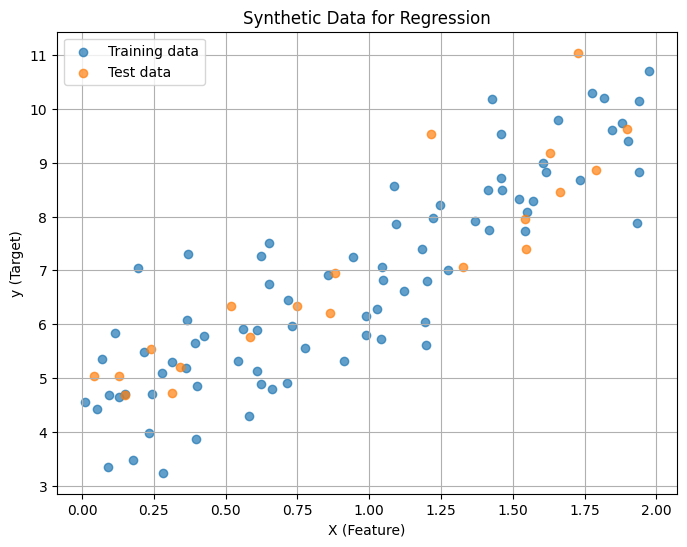

In [ ]:
# Generate synthetic data
np.random.seed(42)
X = 2 * np.random.rand(100, 1) # 100 samples, 1 feature
y = 4 + 3 * X + np.random.randn(100, 1) # y = 4 + 3x + noise

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

plt.figure(figsize=(8, 6))
plt.scatter(X_train, y_train, label='Training data', alpha=0.7)
plt.scatter(X_test, y_test, label='Test data', alpha=0.7)
plt.xlabel('X (Feature)')
plt.ylabel('y (Target)')
plt.title('Synthetic Data for Regression')
plt.legend()
plt.grid(True)
plt.show()

### 2. Implement Ridge Regression

We'll use `Ridge` from `sklearn.linear_model`. The main hyperparameter is `alpha` ($\alpha$), which controls the strength of regularization.

Ridge with alpha=0.0:
  Coefficients: 2.7993
  Intercept: 4.1429
  Mean Squared Error on Test Set: 0.6537

Ridge with alpha=0.1:
  Coefficients: 2.7890
  Intercept: 4.1525
  Mean Squared Error on Test Set: 0.6527

Ridge with alpha=1.0:
  Coefficients: 2.6999
  Intercept: 4.2360
  Mean Squared Error on Test Set: 0.6476

Ridge with alpha=10.0:
  Coefficients: 2.0456
  Intercept: 4.8485
  Mean Squared Error on Test Set: 0.8025



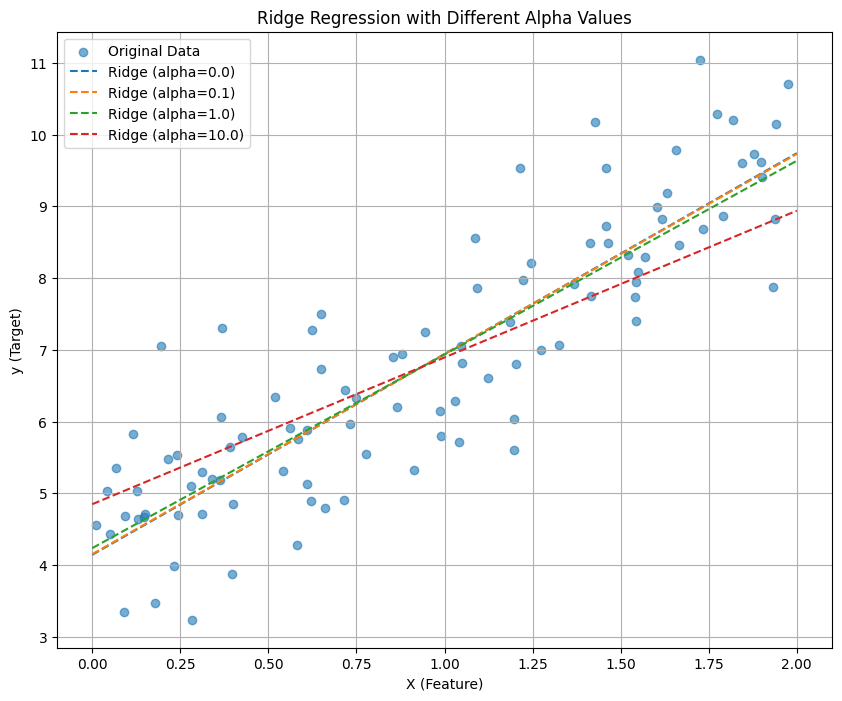

In [ ]:
# Instantiate and fit the Ridge Regression model
# Let's try different alpha values
alphas = [0.0, 0.1, 1.0, 10.0]

plt.figure(figsize=(10, 8))
plt.scatter(X, y, label='Original Data', alpha=0.6)

for alpha in alphas:
    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Evaluate the model
    mse = mean_squared_error(y_test, y_pred)
    print(f'Ridge with alpha={alpha}:')
    print(f'  Coefficients: {model.coef_[0]:.4f}')
    print(f'  Intercept: {model.intercept_[0]:.4f}')
    print(f'  Mean Squared Error on Test Set: {mse:.4f}\n')

    # Plot the regression line
    X_plot = np.linspace(0, 2, 100).reshape(-1, 1)
    y_plot = model.predict(X_plot)
    plt.plot(X_plot, y_plot, label=f'Ridge (alpha={alpha})', linestyle='--')

plt.xlabel('X (Feature)')
plt.ylabel('y (Target)')
plt.title('Ridge Regression with Different Alpha Values')
plt.legend()
plt.grid(True)
plt.show()

### Interpretation of Results

*   **`alpha = 0.0`**: This is equivalent to standard Ordinary Least Squares (OLS) regression. You'll notice the coefficients might be larger, and the MSE reflects the standard linear fit.
*   **Increasing `alpha`**: As `alpha` increases, the regularization strength increases. You'll observe that the magnitude of the `Coefficients` will generally decrease (shrink towards zero), and the regression line might become 'flatter'. The Mean Squared Error (MSE) might initially decrease as `alpha` helps reduce variance, but if `alpha` becomes too large, it can lead to underfitting and an increased MSE as the model becomes too simple.

#Program 1: Student Score Prediction

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

data = {
    "StudyHours":[2,3,4,5,6,7,8,9,10,11],
    "Attendance":[60,65,70,75,80,85,90,92,95,98],
    "Marks":[45,50,55,60,68,74,80,86,92,97]
}

df = pd.DataFrame(data)
df.head()

,StudyHours,Attendance,Marks
0,2,60,45
1,3,65,50
2,4,70,55
3,5,75,60
4,6,80,68


In [ ]:
X = df[["StudyHours","Attendance"]]
y = df["Marks"]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = Ridge(alpha=1.0)
model.fit(X_train, y_train)


Ridge()

In [ ]:
prediction = model.predict(X_test)


In [ ]:
print("Predictions:", prediction)
print("MSE:", mean_squared_error(y_test, prediction))

new_data = scaler.transform([[8,90]])
print("Predicted Marks:", model.predict(new_data))

Predictions: [89.27541 50.4777 ]
MSE: 3.825793968053086
Predicted Marks: [80.32876429]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


#Program 2: House Price Prediction

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

data = {
    "Area":[1000,1200,1500,1800,2000,2200,2500,2700],
    "Bedrooms":[2,2,3,3,4,4,5,5],
    "Age":[15,12,10,8,6,5,3,2],
    "Price":[25,30,38,45,52,58,65,72]
}

df = pd.DataFrame(data)
df.head()

,Area,Bedrooms,Age,Price
0,1000,2,15,25
1,1200,2,12,30
2,1500,3,10,38
3,1800,3,8,45
4,2000,4,6,52


In [ ]:
X = df[["Area","Bedrooms","Age"]]
y = df["Price"]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = Ridge(alpha=0.5)
model.fit(X_train, y_train)

new_house = scaler.transform([[2100,4,5]])
print("Predicted Price:", model.predict(new_house))

Predicted Price: [55.34888907]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


#Program 3: Car Price Prediction

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

data = {
    "Age":[1,2,3,4,5,6,7,8],
    "Mileage":[10000,20000,30000,40000,50000,60000,70000,80000],
    "Engine":[1200,1300,1400,1500,1600,1700,1800,2000],
    "Price":[9,8.5,8,7.2,6.5,5.8,5,4.2]
}

df = pd.DataFrame(data)

In [ ]:
df.head()

,Age,Mileage,Engine,Price
0,1,10000,1200,9.0
1,2,20000,1300,8.5
2,3,30000,1400,8.0
3,4,40000,1500,7.2
4,5,50000,1600,6.5


In [ ]:
X = df[["Age","Mileage","Engine"]]
y = df["Price"]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

Ridge()

In [ ]:
car = scaler.transform([[3,35000,1500]])
print("Predicted Price:", model.predict(car))

Predicted Price: [7.44247485]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


#Program 4: Diabetes Prediction (Built-in Dataset)

In [ ]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

diabetes = load_diabetes()

X = diabetes.data
y = diabetes.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

prediction = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, prediction))

sample = X_test[0].reshape(1, -1)
print("Prediction:", model.predict(sample))

MSE: 2892.0145657501726
Prediction: [139.86277405]
